#### Varadharajan K, CB.SC.P2AIE25030 - 24AI636 - Deep Learning

#### Project: Voice-Based Stress Detection - Review 3: Autoencoder/ GAN

# Voice-Based Stress Detection using Deep Learning

## Project Overview

This project aims to detect **stress levels from speech signals** using deep learning techniques. Human speech contains acoustic and temporal patterns that reflect emotional and psychological states. By analyzing these patterns, machine learning models can learn to distinguish between **low-stress and high-stress speech signals**.

In **Review 3**, the project is extended to include **generative deep learning models**, specifically:

- Autoencoders for latent feature learning
- Generative Adversarial Networks (GANs) for data generation and distribution modeling

These models help in understanding the **underlying structure of speech representations** and improve insights into stress-related patterns.

---

## Problem Statement

Given an input speech recording, the goal is to:

- Learn meaningful representations of speech features
- Generate realistic feature distributions
- Analyze latent structures of stress-related speech

The problem is approached using both:

- **Reconstruction-based learning (Autoencoder)**
- **Adversarial learning (GAN)**

---

## Dataset

The project uses the **RAVDESS Emotional Speech Audio Dataset**, which contains speech recordings of actors expressing different emotions.

Dataset Source:  
https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio

Emotion-to-stress mapping used in this project:

| Emotion | Stress Label |
|-------|-------------|
| Neutral | Low Stress |
| Calm | Low Stress |
| Sad | Low Stress |
| Angry | High Stress |
| Fearful | High Stress |
| Disgust | High Stress |
| Surprised | High Stress |

---

## Project Pipeline

The overall workflow of the project is as follows:

1. Audio preprocessing
2. Feature extraction (MFCC / Mel Spectrogram)
3. Data visualization and exploratory analysis
4. Latent representation learning (Autoencoder)
5. Generative modeling (GAN)
6. Model training with validation and early stopping
7. Hyperparameter tuning (learning rate, batch size)
8. Latent space visualization (PCA and t-SNE)
9. Generated output evaluation and comparison
10. Performance analysis and interpretation

---

## Deep Learning Models Explored

### Review 1 – Baseline Models
- Multi-Layer Perceptron (MLP)
- Convolutional Neural Network (CNN)

### Review 2 – Advanced Models
Sequence Models:
- Recurrent Neural Network (RNN)
- Long Short-Term Memory (LSTM)
- Gated Recurrent Unit (GRU)
- Attention-based LSTM

Transfer Learning Models:
- ResNet18
- MobileNetV2

### Review 3 – Generative Models

#### Autoencoder
- Learns compressed **latent representations** of speech features
- Enables reconstruction of input signals
- Helps analyze feature quality and redundancy

#### Generative Adversarial Network (GAN)
- Generator learns to produce realistic feature vectors
- Discriminator distinguishes real vs generated samples
- Captures underlying data distribution

---

## Training Strategy and Stability

To ensure stable and effective training:

- **Early Stopping** is used to prevent overfitting
- **Batch Normalization** improves convergence
- **Label Smoothing** stabilizes GAN training
- Balanced training between Generator and Discriminator is maintained
- Hyperparameter tuning is performed for:
  - Learning rate
  - Batch size

---

## Evaluation Metrics and Analysis

### Autoencoder Evaluation
- Reconstruction Mean Squared Error (MSE)
- Error distribution analysis
- Train vs Test reconstruction comparison (generalization)

### GAN Evaluation
- Statistical comparison (mean and standard deviation)
- Distribution overlap (real vs generated)
- Diversity analysis of generated samples

### Visualization Techniques
- **PCA (Principal Component Analysis)** for global structure
- **t-SNE (t-Distributed Stochastic Neighbor Embedding)** for local clustering
- Latent space visualization to observe stress separation

---

## Key Observations

- Autoencoder successfully learns compact representations of speech features
- Latent space shows meaningful clustering of stress categories
- GAN is able to generate realistic feature distributions
- No significant mode collapse observed (verified using diversity metrics)
- Model generalization is validated through train vs test comparisons

---

## Expected Learning Outcomes

This project demonstrates:

- Representation learning using autoencoders
- Generative modeling using GANs
- Latent space analysis and visualization
- Training stability techniques in deep learning
- Quantitative and qualitative evaluation of models
- Comparative understanding of discriminative vs generative approaches

---

## Reproducibility

To ensure reproducible results, the experiments use fixed random seeds for:

- Python random module
- NumPy
- PyTorch

---

## Author
Varadharajan K <br> 
Deep Learning Project: Voice-Based Stress Detection

In [ ]:
#downloading the required libraries
!pip install torch torchvision torchaudio librosa numpy scikit-learn matplotlib seaborn kagglehub -q


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
#importing the required libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import librosa, librosa.display
import os, random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from collections import Counter
import kagglehub

c:\Users\VARADHARAJAN K\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
#reproducibility of results
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [ ]:
#downloading the RAVDESS dataset using kagglehub
path = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")
print("Dataset Path:", path)

Dataset Path: C:\Users\VARADHARAJAN K\.cache\kagglehub\datasets\uwrfkaggler\ravdess-emotional-speech-audio\versions\1


In [ ]:
#class for audio feature extraction
class AudioFeatureExtractor:

    def __init__(self, sr=22050, n_mfcc=40):
        self.sr = sr
        self.n_mfcc = n_mfcc

    def load(self, file):
        signal, _ = librosa.load(file, sr=self.sr)
        return signal

    def normalize(self, x):
        return (x - np.mean(x)) / (np.std(x) + 1e-6)

    def pad_seq(self, feat, max_len=173):
        if feat.shape[0] < max_len:
            pad = max_len - feat.shape[0]
            feat = np.pad(feat, ((0,pad),(0,0)))
        else:
            feat = feat[:max_len]
        return feat

    def pad_mel(self, mel, max_len=173):
        if mel.shape[1] < max_len:
            pad = max_len - mel.shape[1]
            mel = np.pad(mel, ((0,0),(0,pad)))
        else:
            mel = mel[:,:max_len]
        return mel

    def extract_mfcc(self, signal):
        mfcc = librosa.feature.mfcc(y=signal, sr=self.sr, n_mfcc=self.n_mfcc)
        mfcc = mfcc.T
        mfcc = self.pad_seq(mfcc)
        return self.normalize(mfcc)

    def extract_mel(self, signal):
        mel = librosa.feature.melspectrogram(y=signal, sr=self.sr)
        mel = librosa.power_to_db(mel, ref=np.max)
        mel = self.pad_mel(mel)
        return self.normalize(mel)

In [ ]:
#class for RAVDESS dataset
class RAVDESSDataset(Dataset):

    def __init__(self, root_dir, mode="mfcc"):
        self.root = root_dir
        self.mode = mode
        self.extractor = AudioFeatureExtractor()
        self.files = []
        self.labels = []
        self._load()

    def _emotion_to_stress(self, eid):
        eid = int(eid)
        if eid in [1,2,4]: return 0
        if eid in [5,6,7,8]: return 1
        return None

    def _load(self):
        for actor in os.listdir(self.root):
            actor_path = os.path.join(self.root, actor)
            for file in os.listdir(actor_path):
                if file.endswith(".wav"):
                    eid = file.split("-")[2]
                    label = self._emotion_to_stress(eid)
                    if label is not None:
                        self.files.append(os.path.join(actor_path,file))
                        self.labels.append(label)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        file = self.files[idx]
        label = self.labels[idx]
        signal = self.extractor.load(file)

        if self.mode == "mfcc":
            feat = self.extractor.extract_mfcc(signal)
            return torch.tensor(feat,dtype=torch.float32),torch.tensor(label)

        mel = self.extractor.extract_mel(signal)
        return torch.tensor(mel,dtype=torch.float32).unsqueeze(0),torch.tensor(label)

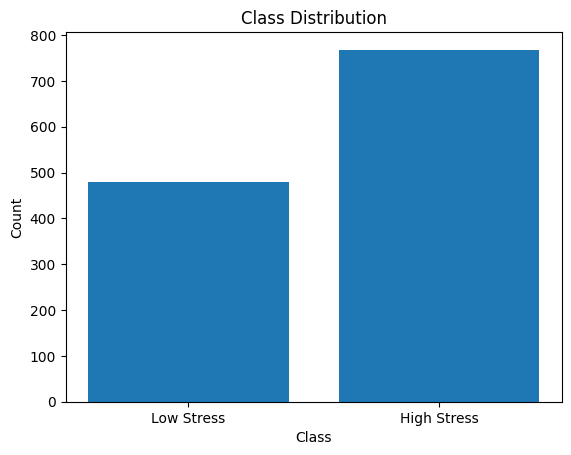

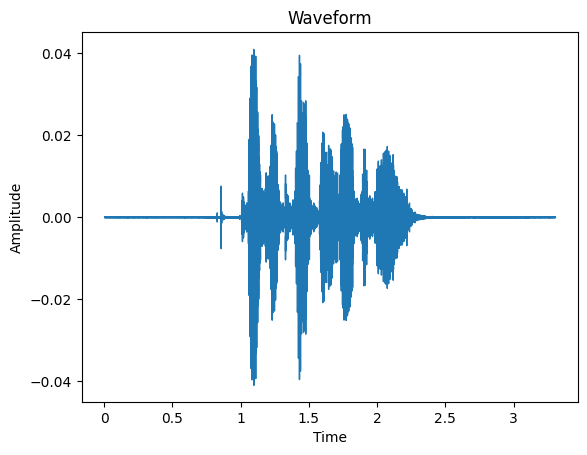

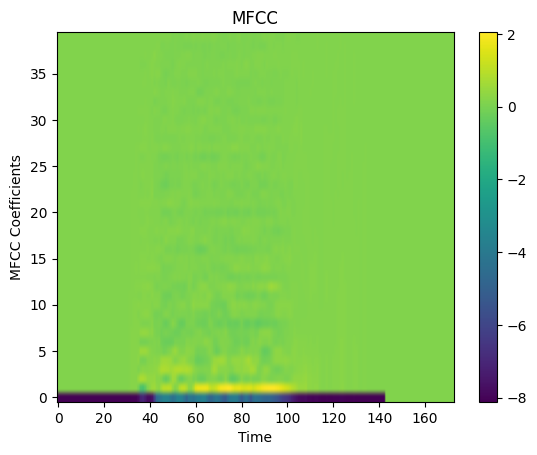

In [ ]:
#visualization of the dataset
dataset_vis = RAVDESSDataset(path,"mfcc")
counts = Counter(dataset_vis.labels)

plt.figure()
plt.bar(["Low Stress","High Stress"],[counts[0],counts[1]])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

extractor = AudioFeatureExtractor()
signal = extractor.load(dataset_vis.files[0])

librosa.display.waveshow(signal)
plt.title("Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

mfcc = extractor.extract_mfcc(signal)
plt.imshow(mfcc.T,aspect="auto",origin="lower")
plt.title("MFCC")
plt.xlabel("Time")
plt.ylabel("MFCC Coefficients")
plt.colorbar()
plt.show()

In [ ]:
#function to split the dataset into train, validation and test sets
def prepare_data(mode):
    dataset = RAVDESSDataset(path,mode)
    idx=list(range(len(dataset)))
    labels=dataset.labels

    train_idx,temp_idx=train_test_split(idx,test_size=0.3, stratify=labels,random_state=42)
    temp_labels=[labels[i] for i in temp_idx]

    val_idx,test_idx=train_test_split(temp_idx,test_size=0.5, stratify=temp_labels,random_state=42)

    train=torch.utils.data.Subset(dataset,train_idx)
    val=torch.utils.data.Subset(dataset,val_idx)
    test=torch.utils.data.Subset(dataset,test_idx)

    return train,val,test

In [ ]:
#function to get dataloaders for train, validation and test sets
def get_loaders(mode="mfcc", batch_size=32):
    train,val,test = prepare_data(mode)
    return (
        DataLoader(train,batch_size=batch_size,shuffle=True),
        DataLoader(val,batch_size=batch_size),
        DataLoader(test,batch_size=batch_size)
    )

In [ ]:
#class for the autoencoder model
class Autoencoder(nn.Module):
    def __init__(self, input_dim=40, latent_dim=16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim,128), nn.ReLU(), nn.BatchNorm1d(128),
            nn.Linear(128,64), nn.ReLU(),
            nn.Linear(64,latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim,64), nn.ReLU(),
            nn.Linear(64,128), nn.ReLU(),
            nn.Linear(128,input_dim)
        )
    def forward(self,x):
        z = self.encoder(x)
        return self.decoder(z), z

In [ ]:
#classes for the GAN models
class Generator(nn.Module):
    def __init__(self, latent_dim=16, output_dim=40):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim,64), nn.ReLU(),
            nn.Linear(64,128), nn.ReLU(),
            nn.Linear(128,output_dim)
        )
    def forward(self,z): return self.net(z)

class Discriminator(nn.Module):
    def __init__(self,input_dim=40):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim,128), nn.LeakyReLU(0.2),
            nn.Linear(128,64), nn.LeakyReLU(0.2),
            nn.Linear(64,1), nn.Sigmoid()
        )
    def forward(self,x): return self.net(x)

In [ ]:
#loss functions
ae_loss_fn = nn.MSELoss()
gan_loss_fn = nn.BCELoss()

In [ ]:
#class for early stopping
class EarlyStopping:
    def __init__(self, patience=7):
        self.best=None
        self.count=0
        self.stop=False
        self.patience=patience
    def __call__(self,loss):
        if self.best is None or loss<self.best:
            self.best=loss
            self.count=0
        else:
            self.count+=1
            if self.count>=self.patience:
                self.stop=True

In [ ]:
#function to train the autoencoder model
def train_ae(model,train_loader,val_loader,lr):
    opt=optim.Adam(model.parameters(),lr=lr)
    stopper=EarlyStopping()

    tr,vl=[],[]

    for e in range(50):
        model.train()
        tl=0
        for x,_ in train_loader:
            x=x.mean(dim=1).to(device)
            r,_=model(x)
            loss=ae_loss_fn(r,x)

            opt.zero_grad()
            loss.backward()
            opt.step()
            tl+=loss.item()

        model.eval()
        v=0
        with torch.no_grad():
            for x,_ in val_loader:
                x=x.mean(dim=1).to(device)
                r,_=model(x)
                v+=ae_loss_fn(r,x).item()

        tl/=len(train_loader)
        v/=len(val_loader)

        tr.append(tl)
        vl.append(v)

        print(f"AE Epoch {e+1} | Train {tl:.4f} | Val {v:.4f}")

        stopper(v)
        if stopper.stop:
            print("AE Early Stop")
            break

    return tr,vl

In [ ]:
#function to train the GAN model
def train_gan(G,D,loader,lr):
    optG=optim.Adam(G.parameters(),lr=lr)
    optD=optim.Adam(D.parameters(),lr=lr)

    gL,dL=[],[]

    for e in range(50):
        gl,dl=0,0
        for x,_ in loader:
            x=x.mean(dim=1).to(device)
            bs=x.size(0)

            # Label smoothing for stability
            real=torch.ones(bs,1).to(device)*0.9
            fake=torch.zeros(bs,1).to(device)

            # Train Discriminator
            D.zero_grad()
            lossD=gan_loss_fn(D(x),real)

            z=torch.randn(bs,16).to(device)
            fx=G(z)
            lossD+=gan_loss_fn(D(fx.detach()),fake)
            lossD.backward()
            optD.step()

            # Train Generator
            G.zero_grad()
            lossG=gan_loss_fn(D(fx),real)
            lossG.backward()
            optG.step()

            gl+=lossG.item()
            dl+=lossD.item()

        gL.append(gl/len(loader))
        dL.append(dl/len(loader))

        print(f"GAN Epoch {e+1} | G {gL[-1]:.4f} | D {dL[-1]:.4f}")

    return gL,dL

In [ ]:
#function to perform hyperparameter tuning for the autoencoder model
def tune():
    best=(1e9,None,None)
    for lr in [1e-3,5e-4]:
        for bs in [16,32]:
            print(f"Testing lr={lr}, bs={bs}")
            tr,vl,_=get_loaders("mfcc",bs)
            m=Autoencoder().to(device)
            _,vloss=train_ae(m,tr,vl,lr)
            if vloss[-1]<best[0]:
                best=(vloss[-1],lr,bs)
    print("Best:",best)
    return best[1],best[2]

In [ ]:
#function to evaluate the autoencoder model with advanced metrics and visualizations
def evaluate_autoencoder_advanced(model,loader):
    model.eval()
    errs=[]
    with torch.no_grad():
        for x,_ in loader:
            x=x.mean(dim=1).to(device)
            r,_=model(x)
            e=((x-r)**2).mean(dim=1)
            errs.extend(e.cpu().numpy())

    print("Mean MSE:",np.mean(errs))
    print("Std MSE:",np.std(errs))

    plt.figure()
    sns.histplot(errs,bins=30,kde=True)
    plt.title("AE Error Distribution")
    plt.xlabel("MSE")
    plt.ylabel("Frequency")
    plt.show()

def evaluate_gan_advanced(G,loader):
    real,fake=[],[]
    with torch.no_grad():
        for x,_ in loader:
            x=x.mean(dim=1)
            real.append(x.numpy())

            z=torch.randn(x.size(0),16)
            f=G(z).detach().numpy()
            fake.append(f)

    real=np.vstack(real)
    fake=np.vstack(fake)

    print("Mean Diff:",abs(real.mean()-fake.mean()))
    print("Std Diff:",abs(real.std()-fake.std()))

    plt.figure()
    sns.kdeplot(real.flatten(),label="Real")
    sns.kdeplot(fake.flatten(),label="Fake")
    plt.title("Real vs Generated Distribution")
    plt.xlabel("Value")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

def check_mode_collapse(G):
    z=torch.randn(100,16)
    out=G(z).detach().numpy()
    d=np.std(out)
    print("Diversity:",d)
    if d<0.1:
        print("Mode Collapse")
    else:
        print("Good Diversity")

In [ ]:
#function to visualize the latent space of the autoencoder model using PCA and t-SNE
def latent_vis(model,loader):
    Z,Y=[],[]
    with torch.no_grad():
        for x,y in loader:
            x=x.mean(dim=1).to(device)
            _,z=model(x)
            Z.append(z.cpu().numpy())
            Y.extend(y.numpy())

    Z=np.vstack(Z)

    # PCA
    p=PCA(2).fit_transform(Z)
    plt.figure()
    sns.scatterplot(x=p[:,0],y=p[:,1],hue=Y,palette="coolwarm")
    plt.title("PCA Latent Space")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend(title="Stress")
    plt.show()

    # TSNE
    t=TSNE(2,random_state=42).fit_transform(Z)
    plt.figure()
    sns.scatterplot(x=t[:,0],y=t[:,1],hue=Y,palette="coolwarm")
    plt.title("t-SNE Latent Space")
    plt.xlabel("Dim1")
    plt.ylabel("Dim2")
    plt.legend(title="Stress")
    plt.show()

In [ ]:
#function to visualize the reconstructions of the autoencoder model and the outputs of the GAN model
def show_recon(model,loader):
    x,_=next(iter(loader))
    x=x.mean(dim=1).to(device)
    r,_=model(x)

    for i in range(3):
        plt.figure()
        plt.plot(x[i].cpu(),label="Original")
        plt.plot(r[i].detach().cpu(),label="Reconstructed")
        plt.title("Autoencoder Reconstruction")
        plt.xlabel("Feature Index")
        plt.ylabel("Value")
        plt.legend()
        plt.show()

def show_gan(G,loader):
    x,_=next(iter(loader))
    real=x.mean(dim=1)

    z=torch.randn(real.size(0),16)
    fake=G(z).detach()

    for i in range(3):
        plt.figure()
        plt.plot(real[i],label="Real")
        plt.plot(fake[i],label="Generated")
        plt.title("GAN Output Comparison")
        plt.xlabel("Feature Index")
        plt.ylabel("Value")
        plt.legend()
        plt.show()

def show_gan_diversity(G):
    z=torch.randn(5,16)
    fake=G(z).detach()

    for i in range(5):
        plt.figure()
        plt.plot(fake[i])
        plt.title(f"Generated Sample {i+1}")
        plt.xlabel("Feature Index")
        plt.ylabel("Value")
        plt.show()

In [ ]:
#function to compare the train and test error distributions of the autoencoder model
def compare_train_test_ae(model,train_loader,test_loader):
    model.eval()
    train_err,test_err=[],[]

    with torch.no_grad():
        for x,_ in train_loader:
            x=x.mean(dim=1).to(device)
            r,_=model(x)
            train_err.extend(((x-r)**2).mean(dim=1).cpu().numpy())

        for x,_ in test_loader:
            x=x.mean(dim=1).to(device)
            r,_=model(x)
            test_err.extend(((x-r)**2).mean(dim=1).cpu().numpy())

    plt.figure()
    sns.kdeplot(train_err,label="Train")
    sns.kdeplot(test_err,label="Test")
    plt.title("Train vs Test Error")
    plt.xlabel("MSE")
    plt.ylabel("Density")
    plt.legend()
    plt.show()

In [ ]:
#function to perform the final summary of results and insights
def final_summary(ae,G,test_loader):
    print("\n===== FINAL SUMMARY =====")

    errs=[]
    with torch.no_grad():
        for x,_ in test_loader:
            x=x.mean(dim=1).to(device)
            r,_=ae(x)
            errs.extend(((x-r)**2).mean(dim=1).cpu().numpy())

    print("AE Test MSE:",np.mean(errs))

    real,fake=[],[]
    for x,_ in test_loader:
        x=x.mean(dim=1)
        real.append(x.numpy())
        fake.append(G(torch.randn(x.size(0),16)).detach().numpy())

    real=np.vstack(real)
    fake=np.vstack(fake)

    print("GAN Mean Diff:",abs(real.mean()-fake.mean()))
    print("GAN Std Diff:",abs(real.std()-fake.std()))

Testing lr=0.001, bs=16
AE Epoch 1 | Train 0.3653 | Val 0.1277
AE Epoch 2 | Train 0.0222 | Val 0.0094
AE Epoch 3 | Train 0.0060 | Val 0.0037
AE Epoch 4 | Train 0.0037 | Val 0.0035
AE Epoch 5 | Train 0.0027 | Val 0.0022
AE Epoch 6 | Train 0.0023 | Val 0.0022
AE Epoch 7 | Train 0.0019 | Val 0.0016
AE Epoch 8 | Train 0.0018 | Val 0.0019
AE Epoch 9 | Train 0.0017 | Val 0.0018
AE Epoch 10 | Train 0.0016 | Val 0.0015
AE Epoch 11 | Train 0.0015 | Val 0.0013
AE Epoch 12 | Train 0.0016 | Val 0.0014
AE Epoch 13 | Train 0.0014 | Val 0.0012
AE Epoch 14 | Train 0.0014 | Val 0.0013
AE Epoch 15 | Train 0.0014 | Val 0.0013
AE Epoch 16 | Train 0.0015 | Val 0.0013
AE Epoch 17 | Train 0.0013 | Val 0.0014
AE Epoch 18 | Train 0.0013 | Val 0.0013
AE Epoch 19 | Train 0.0013 | Val 0.0011
AE Epoch 20 | Train 0.0015 | Val 0.0020
AE Epoch 21 | Train 0.0017 | Val 0.0011
AE Epoch 22 | Train 0.0016 | Val 0.0012
AE Epoch 23 | Train 0.0015 | Val 0.0011
AE Epoch 24 | Train 0.0014 | Val 0.0011
AE Epoch 25 | Train 0.001

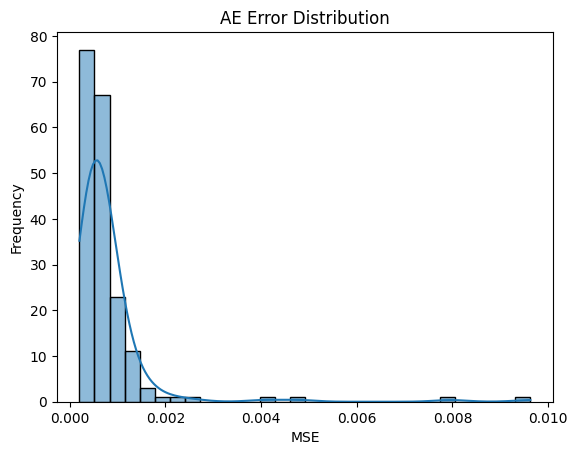

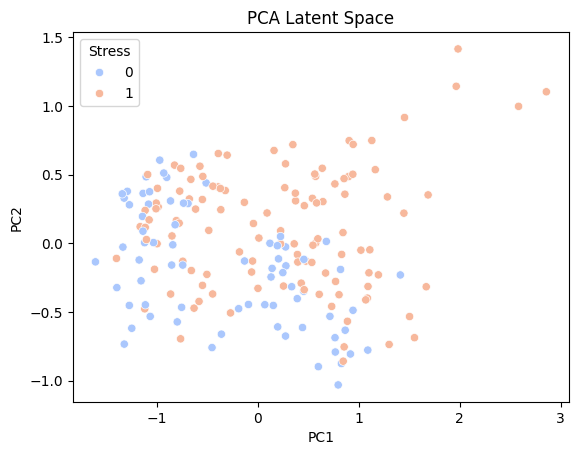

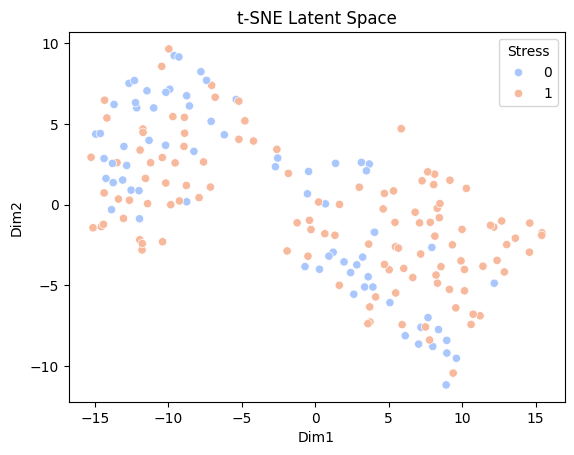

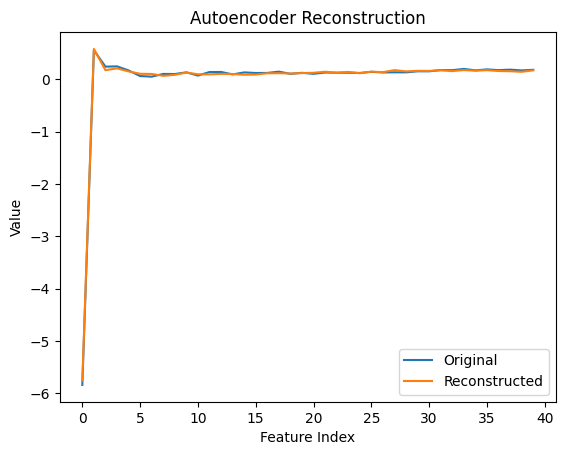

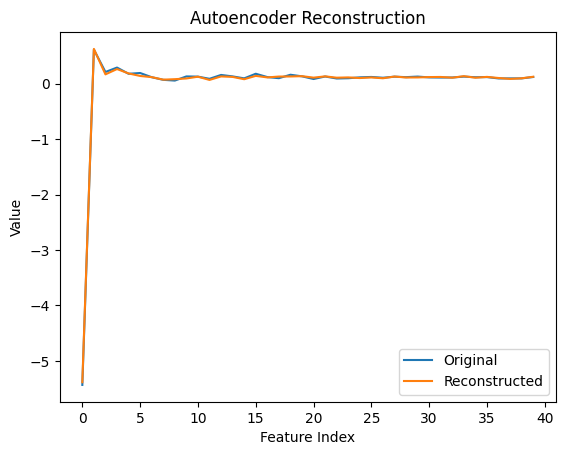

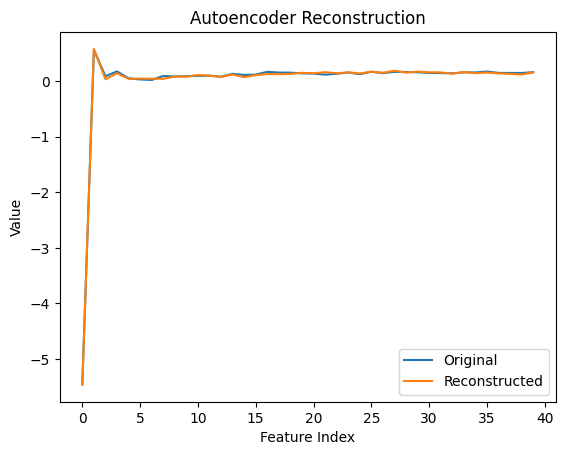

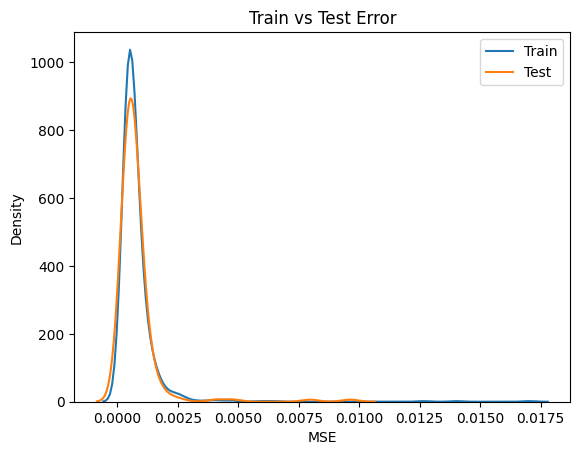

GAN Epoch 1 | G 0.7245 | D 1.0894
GAN Epoch 2 | G 1.0397 | D 0.9550
GAN Epoch 3 | G 1.4164 | D 1.0100
GAN Epoch 4 | G 2.2831 | D 0.6296
GAN Epoch 5 | G 2.8757 | D 0.4564
GAN Epoch 6 | G 3.0237 | D 0.4021
GAN Epoch 7 | G 2.0033 | D 0.6576
GAN Epoch 8 | G 1.5001 | D 1.0720
GAN Epoch 9 | G 1.9714 | D 0.6767
GAN Epoch 10 | G 1.8114 | D 0.5994
GAN Epoch 11 | G 1.4769 | D 0.7206
GAN Epoch 12 | G 1.5409 | D 0.9065
GAN Epoch 13 | G 1.6914 | D 0.8703
GAN Epoch 14 | G 2.0578 | D 0.5937
GAN Epoch 15 | G 2.0967 | D 0.5876
GAN Epoch 16 | G 2.0311 | D 0.6394
GAN Epoch 17 | G 1.8912 | D 0.7849
GAN Epoch 18 | G 2.0662 | D 0.6769
GAN Epoch 19 | G 2.2469 | D 0.5617
GAN Epoch 20 | G 2.0244 | D 0.6294
GAN Epoch 21 | G 1.6745 | D 0.9127
GAN Epoch 22 | G 1.9436 | D 0.8653
GAN Epoch 23 | G 2.3693 | D 0.6412
GAN Epoch 24 | G 2.1592 | D 0.5750
GAN Epoch 25 | G 1.9205 | D 0.7469
GAN Epoch 26 | G 1.7532 | D 0.9452
GAN Epoch 27 | G 1.9726 | D 1.0030
GAN Epoch 28 | G 2.3889 | D 0.6240
GAN Epoch 29 | G 1.9809 | D 0

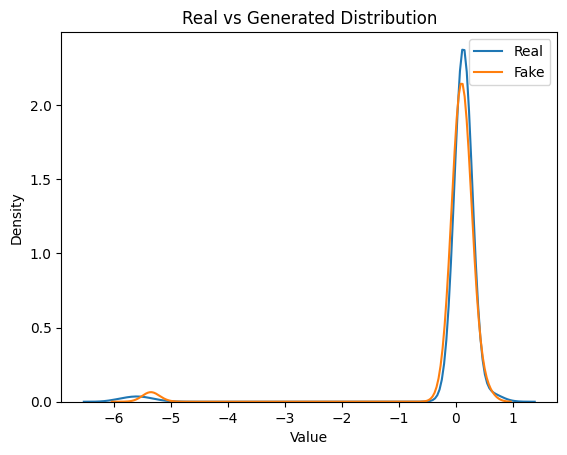

Diversity: 0.860512
Good Diversity


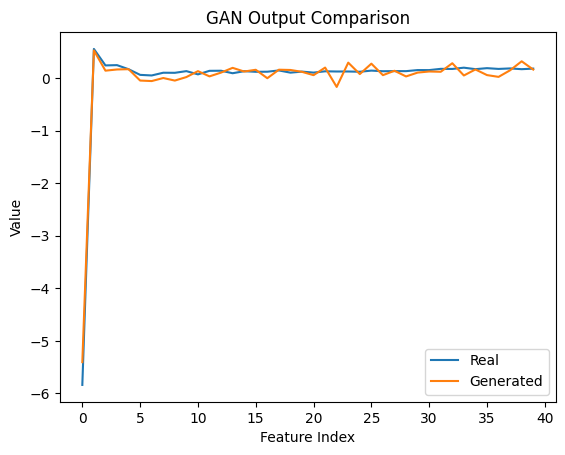

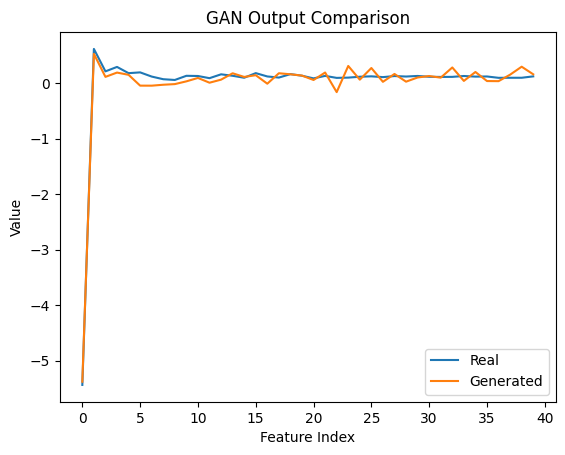

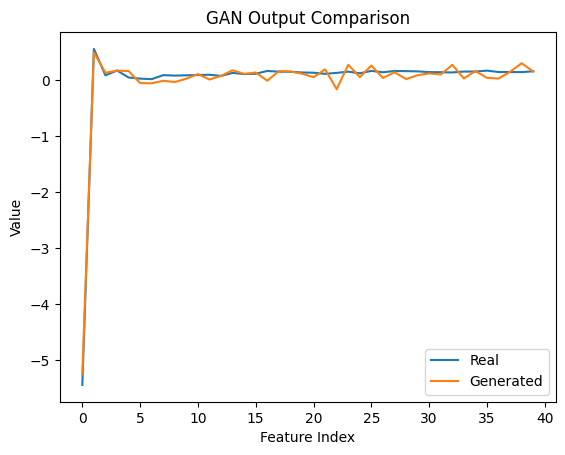

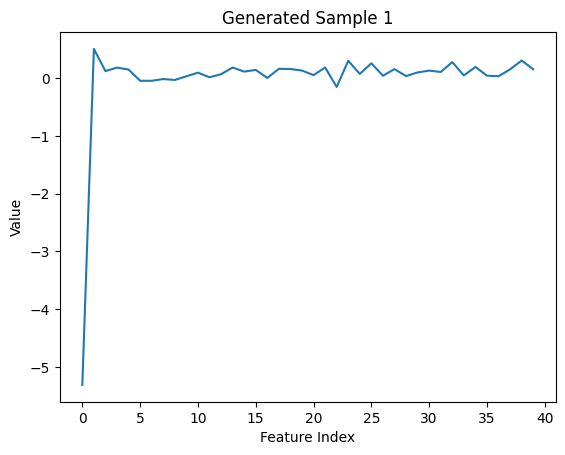

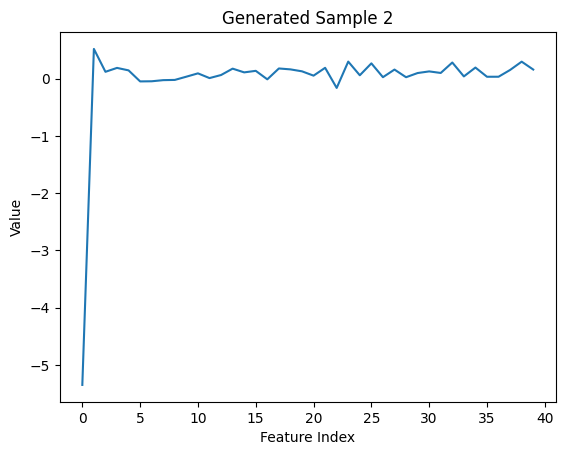

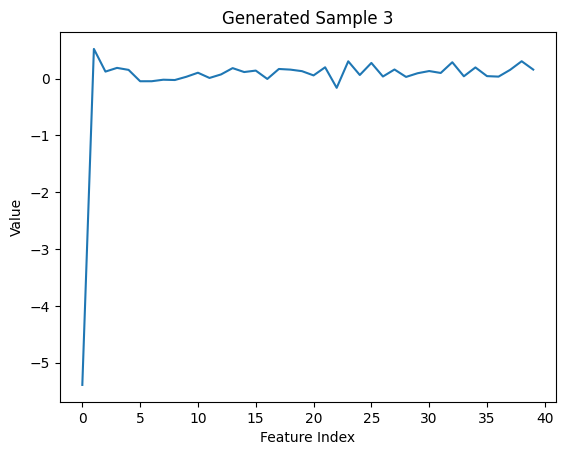

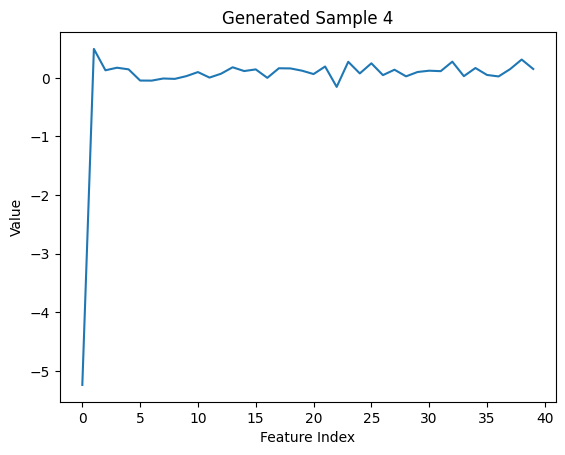

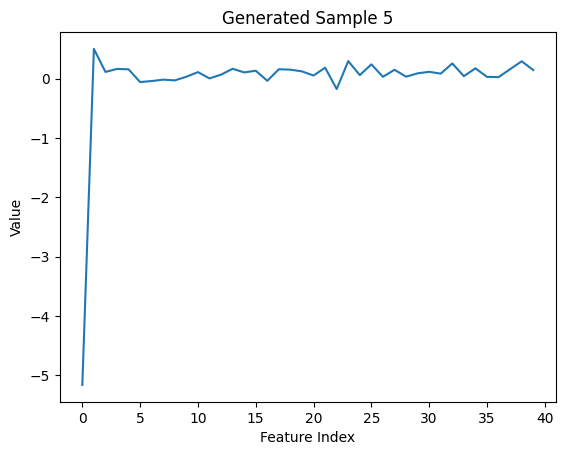


===== FINAL SUMMARY =====
AE Test MSE: 0.00078556006
GAN Mean Diff: 0.023843948
GAN Std Diff: 0.04207194


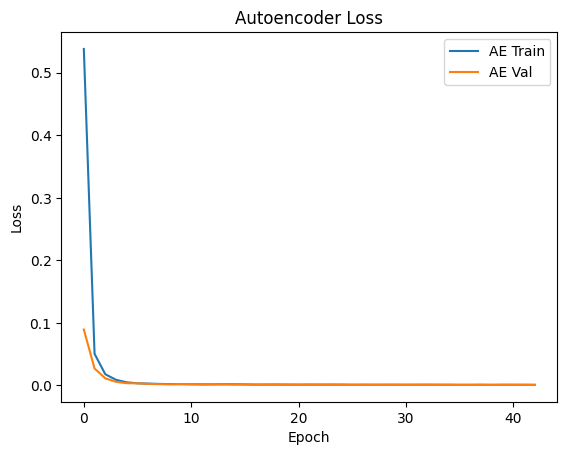

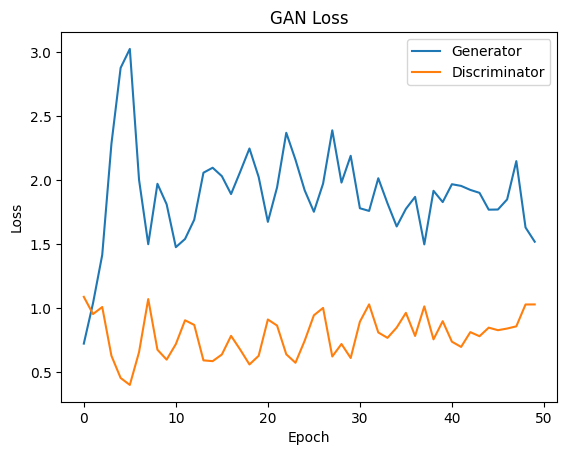

In [ ]:
# MAIN EXECUTION
lr,bs=tune()

train_loader,val_loader,test_loader=get_loaders("mfcc",bs)

# AE
ae=Autoencoder().to(device)
ae_tr,ae_val=train_ae(ae,train_loader,val_loader,lr)

print("Final Train Loss:",ae_tr[-1])
print("Final Val Loss:",ae_val[-1])

evaluate_autoencoder_advanced(ae,test_loader)
latent_vis(ae,test_loader)
show_recon(ae,test_loader)
compare_train_test_ae(ae,train_loader,test_loader)

# GAN
G=Generator().to(device)
D=Discriminator().to(device)

gL,dL=train_gan(G,D,train_loader,lr)

evaluate_gan_advanced(G,test_loader)
check_mode_collapse(G)
show_gan(G,test_loader)
show_gan_diversity(G)

# SUMMARY
final_summary(ae,G,test_loader)

# LOSS CURVES
plt.figure()
plt.plot(ae_tr,label="AE Train")
plt.plot(ae_val,label="AE Val")
plt.title("Autoencoder Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure()
plt.plot(gL,label="Generator")
plt.plot(dL,label="Discriminator")
plt.title("GAN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()